<a href="https://colab.research.google.com/github/hemanthg3/Model-Tuning-Validation/blob/main/Model_Tuning_%26_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
import xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

import pickle

# **Load Dataset**

In [ ]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


# **Understanding**

In [ ]:
print(df.shape)
df.info()
df.isnull().sum()

(48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


# **Data Cleaning**

In [ ]:
# Replace missing values marked as '?'
df.replace(' ?', np.nan, inplace=True)

df.dropna(inplace=True)

# **Encode Target Variable**

In [ ]:
# Target column usually 'income'
print("Unique values in 'income' before mapping:", df['income'].unique())
print("Value counts before mapping:\n", df['income'].value_counts())
df['income'] = df['income'].astype(str).str.strip().map({'<=50K': 0, '>50K': 1})

Unique values in 'income' before mapping: ['<=50K' '>50K']
Value counts before mapping:
 income
<=50K    37155
>50K     11687
Name: count, dtype: int64


# **Feature Engineering**

In [ ]:
# Convert categorical columns into numeric
df = pd.get_dummies(df, drop_first=True)

# **Split Features & Target**

In [ ]:
X = df.drop('income', axis=1)
y = df['income']

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **Baseline XGBoost Model**

In [98]:
base_model = XGBClassifier(eval_metric='logloss')

base_model.fit(X_train, y_train)

y_pred = base_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.8759340771829256


# **Hyperparameter Tuning**

In [99]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [50, 100], 'subsample': [0.8, 1]},
             scoring='accuracy', verbose=1)

# **Best Model**

In [ ]:
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1}


# **Evaluate Tuned Model**

In [ ]:
y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Tuned Accuracy: 0.8753198894462074

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      7431
           1       0.80      0.64      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.79      0.82      9769
weighted avg       0.87      0.88      0.87      9769



# **Confusion Matrix**

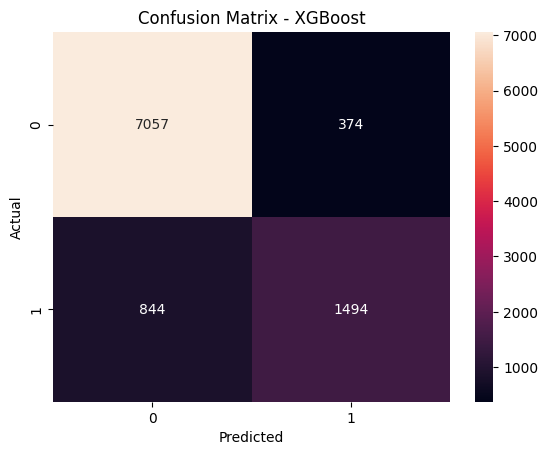

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Save Best Model (.pkl)**

In [ ]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved!")

Best model saved!


# **Save Hyperparameter Results (CSV)**

In [ ]:
results = pd.DataFrame(grid.cv_results_)
results.to_csv("tuning_results.csv", index=False)

print("Hyperparameter results saved!")

Hyperparameter results saved!


# **Feature Importance**

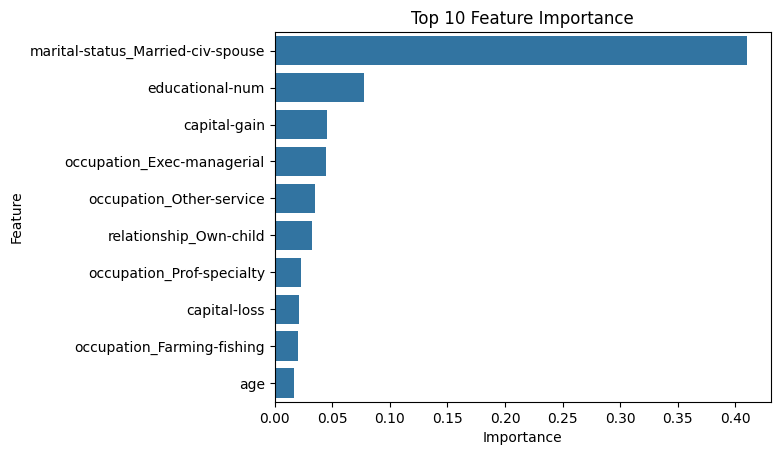

In [ ]:
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Feature Importance")
plt.show()